In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

In [2]:
df = pd.read_csv("../data/electricityConsumptionAndProductioction.csv")

df.head()

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [3]:
df.shape

(62810, 10)

In [4]:
df.columns

Index(['DateTime', 'Consumption', 'Production', 'Nuclear', 'Wind',
       'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62810 entries, 0 to 62809
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   DateTime       62810 non-null  object
 1   Consumption    62810 non-null  int64 
 2   Production     62810 non-null  int64 
 3   Nuclear        62810 non-null  int64 
 4   Wind           62810 non-null  int64 
 5   Hydroelectric  62810 non-null  int64 
 6   Oil and Gas    62810 non-null  int64 
 7   Coal           62810 non-null  int64 
 8   Solar          62810 non-null  int64 
 9   Biomass        62810 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 4.8+ MB


In [6]:
df.isna().sum()

DateTime         0
Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64

In [7]:
df["DateTime"] = pd.to_datetime(df["DateTime"])

In [8]:
df["Year"] = df["DateTime"].dt.year
df["Month"] = df["DateTime"].dt.month
df["Day"] = df["DateTime"].dt.day
df["Hour"] = df["DateTime"].dt.hour
df["DayOfWeek"] = df["DateTime"].dt.day_name()
df["Date"] = df["DateTime"].dt.date

In [9]:
df["Renewables"] = df["Wind"] + df["Hydroelectric"] + df["Solar"] + df["Biomass"]
df["Fossil"] = df["Oil and Gas"] + df["Coal"]
df["Balance"] = df["Production"] - df["Consumption"]
df["RenewableShare"] = df["Renewables"] / df["Production"] * 100
df["FossilShare"] = df["Fossil"] / df["Production"] * 100

In [10]:
df[["Consumption", "Production", "Renewables", "Fossil", "Balance"]].describe()

,Consumption,Production,Renewables,Fossil,Balance
count,62810.000000,62810.000000,62810.000000,62810.000000,62810.000000
mean,6475.453288,6305.888155,2765.965579,2256.604792,-169.565133
std,1062.464918,1041.573099,888.085499,606.247429,827.482906
min,2542.000000,2818.000000,694.000000,394.000000,-3070.000000
25%,5651.000000,5561.000000,2111.000000,1881.000000,-743.000000
50%,6411.000000,6254.000000,2684.000000,2291.000000,-228.000000
75%,7230.000000,6999.000000,3337.000000,2654.000000,366.000000
max,11986.000000,12179.000000,6636.000000,4555.000000,3789.000000


In [26]:
# Figure 1 compares electricity consumption and production using a 30-day rolling average.
# The rolling average reduces short-term noise and highlights long-term trends and possible imbalances.

In [27]:
# Figure 1 presents the 30-day rolling average of electricity consumption and production between 2019 and 2026. 
# The use of a rolling average reduces short-term fluctuations and makes long-term patterns easier to observe. 
# Overall, electricity production follows a similar temporal evolution to consumption, indicating that the production system generally adapts to demand. 
# However, several periods show visible differences between the two lines, suggesting temporary imbalances between national electricity demand and production. 
# The figure also highlights seasonal variation, with repeated increases and decreases across the years.

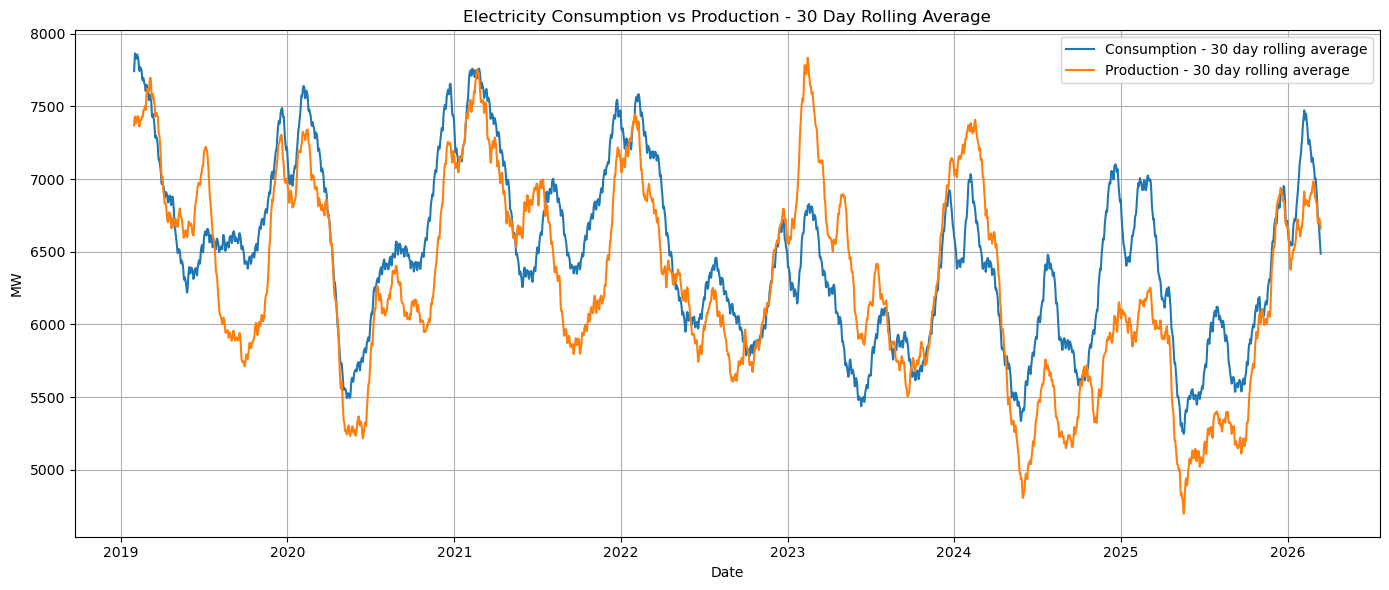

In [19]:
daily = df.groupby("Date")[["Consumption", "Production"]].mean().reset_index()
daily["Date"] = pd.to_datetime(daily["Date"])

daily["Consumption_30d"] = daily["Consumption"].rolling(window=30).mean()
daily["Production_30d"] = daily["Production"].rolling(window=30).mean()

plt.figure(figsize=(14, 6))
plt.plot(daily["Date"], daily["Consumption_30d"], label="Consumption - 30 day rolling average")
plt.plot(daily["Date"], daily["Production_30d"], label="Production - 30 day rolling average")

plt.title("Electricity Consumption vs Production - 30 Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("MW")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/figure1_consumption_vs_production_rolling.png", dpi=300)
plt.show()

In [ ]:
# Figure 2 shows the average electricity consumption by day of week and hour of day.
# This heatmap helps identify daily and weekly demand patterns, including peak and low-consumption periods.

In [ ]:
# Figure 2 shows the average electricity consumption grouped by day of week and hour of day. 
# The heatmap reveals a clear daily pattern: consumption is lowest during nighttime and early morning hours, especially between 00:00 and 05:00. 
# After 06:00, demand increases rapidly and remains high throughout the day. 
# The highest average consumption values appear mainly during weekday evenings, especially from Tuesday to Thursday. 
# Weekend consumption is visibly lower than weekday consumption, with Sunday showing the lowest overall demand pattern.

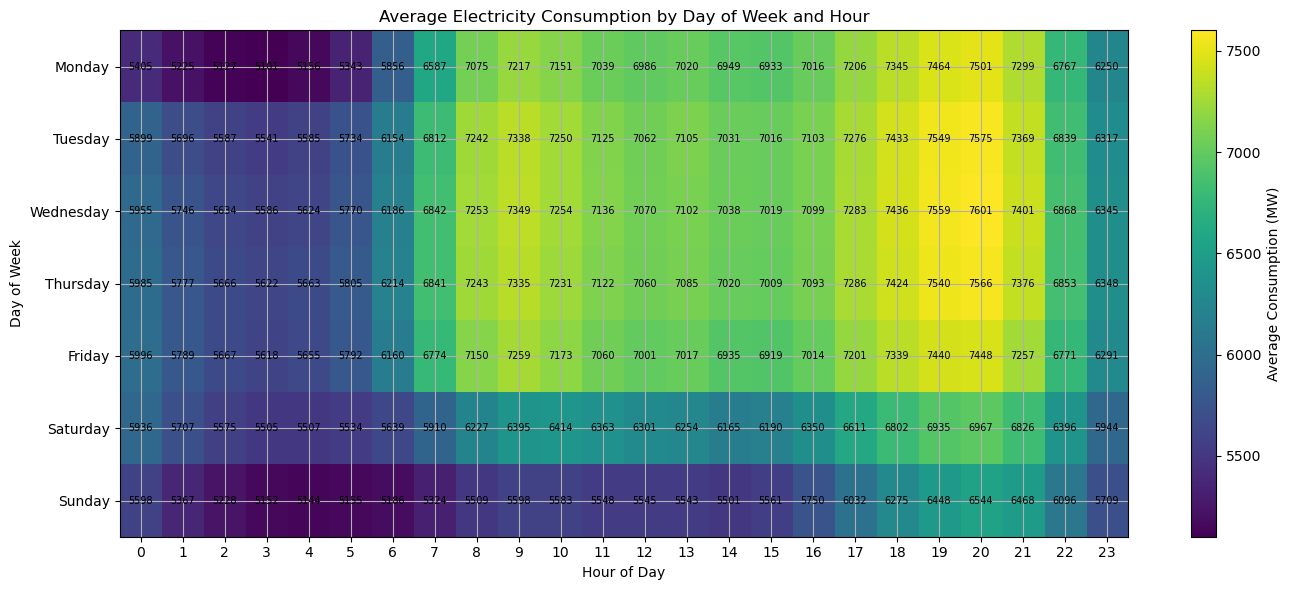

In [21]:
heatmap_data = df.groupby(["DayOfWeek", "Hour"])["Consumption"].mean().unstack()

days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data = heatmap_data.loc[days_order]

plt.figure(figsize=(14, 6))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Average Consumption (MW)")
plt.xticks(range(24), range(24))
plt.yticks(range(len(days_order)), days_order)

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        plt.text(j, i, f"{heatmap_data.iloc[i, j]:.0f}", ha="center", va="center", fontsize=7)

plt.title("Average Electricity Consumption by Day of Week and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.savefig("../figures/figure2_consumption_heatmap.png", dpi=300)
plt.show()

In [ ]:
# Figure 3 visualizes the monthly electricity production mix by source.
# The stacked area chart shows how different energy sources contribute to total production over time.

In [ ]:
# Figure 3 illustrates the monthly average electricity production mix by source. 
# The stacked area chart shows that Romania’s electricity production is composed of several major sources, including nuclear, wind, hydroelectric, oil and gas, coal, solar, and biomass. 
# Nuclear production appears relatively stable across time, acting as a baseline source. 
# In contrast, hydroelectric, wind, coal, and oil and gas display stronger temporal variation. 
# Solar and biomass have smaller contributions compared with the other sources. 
# This figure shows that the electricity production mix is dynamic and changes noticeably from month to month.

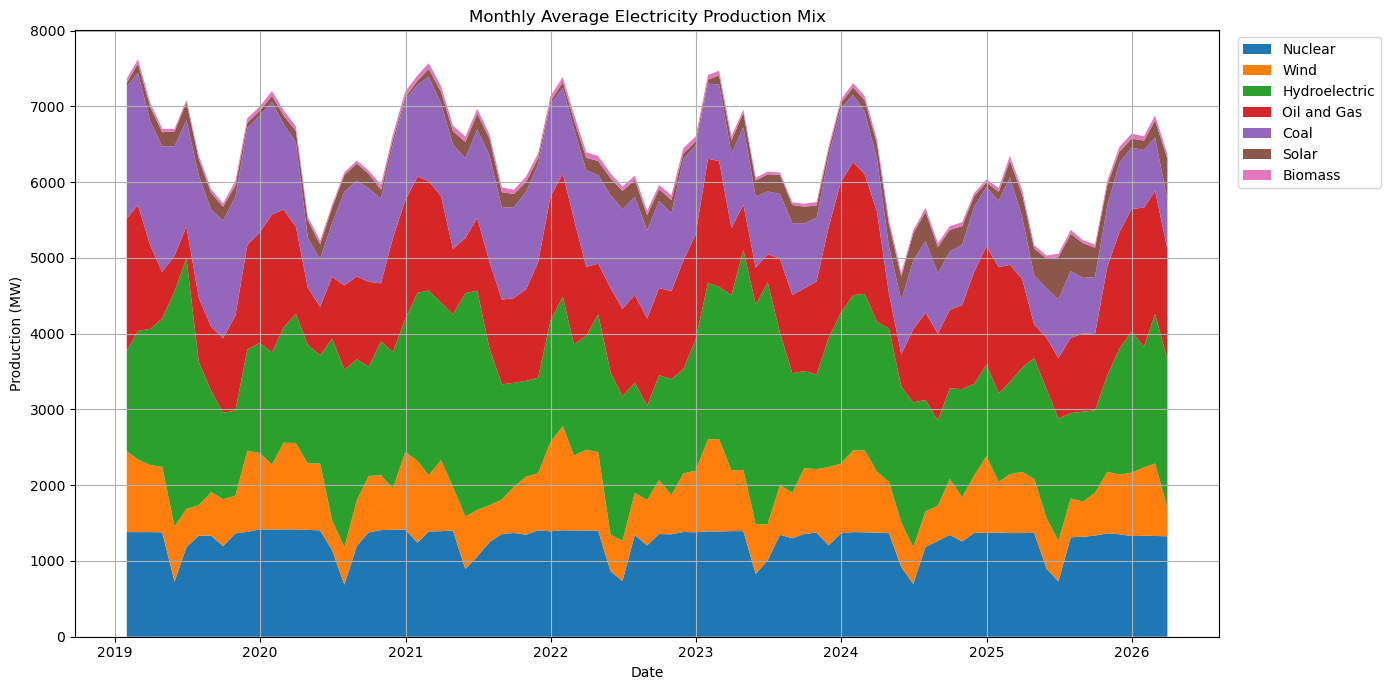

In [22]:
monthly = df.groupby(pd.Grouper(key="DateTime", freq="ME"))[
    ["Nuclear", "Wind", "Hydroelectric", "Oil and Gas", "Coal", "Solar", "Biomass"]
].mean()

plt.figure(figsize=(14, 7))
plt.stackplot(
    monthly.index,
    monthly["Nuclear"],
    monthly["Wind"],
    monthly["Hydroelectric"],
    monthly["Oil and Gas"],
    monthly["Coal"],
    monthly["Solar"],
    monthly["Biomass"],
    labels=["Nuclear", "Wind", "Hydroelectric", "Oil and Gas", "Coal", "Solar", "Biomass"]
)

plt.title("Monthly Average Electricity Production Mix")
plt.xlabel("Date")
plt.ylabel("Production (MW)")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig("../figures/figure3_production_mix.png", dpi=300)
plt.show()

In [ ]:
# Figure 4 shows the distribution of electricity consumption by month.
# The boxplot highlights seasonal differences, variability, and possible outliers in monthly demand.

In [ ]:
# Figure 4 presents the monthly distribution of electricity consumption using boxplots. 
# The figure reveals clear seasonal differences in demand. 
# The highest median consumption values are observed during colder months, especially January, February, November, and December. 
# Lower median values appear during spring and summer months. 
# The spread of the boxplots also differs across months, showing that electricity demand is more variable in some periods than others. 
# Several outliers are visible, indicating unusual episodes of very high or very low consumption within specific months.

<Figure size 1200x600 with 0 Axes>

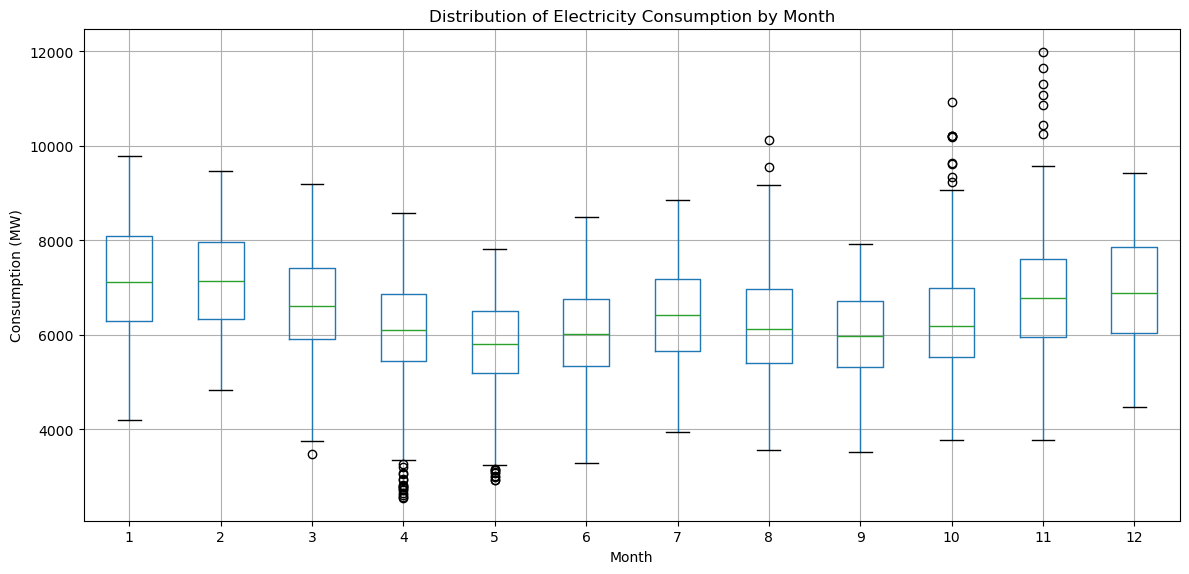

In [15]:
plt.figure(figsize=(12, 6))
df.boxplot(column="Consumption", by="Month", grid=True)

plt.title("Distribution of Electricity Consumption by Month")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("Consumption (MW)")
plt.tight_layout()
plt.savefig("../figures/figure4_monthly_consumption_boxplot.png", dpi=300)
plt.show()

In [ ]:
# Figure 5 shows the correlation matrix between the main electricity variables.
# This visualization helps identify linear relationships between consumption, production, energy sources, and balance.

In [ ]:
# Figure 5 shows the correlation matrix between the main electricity variables. 
# Consumption and production are positively correlated, with a correlation coefficient of 0.69, meaning that production generally increases when consumption increases. 
# Production is strongly correlated with renewable generation, while fossil generation is strongly associated with oil and gas and coal. 
# Consumption is more strongly correlated with fossil sources than with renewable sources, suggesting that fossil generation plays an important role in supporting demand. 
# The matrix also shows a positive relationship between renewable generation and the production-consumption balance.

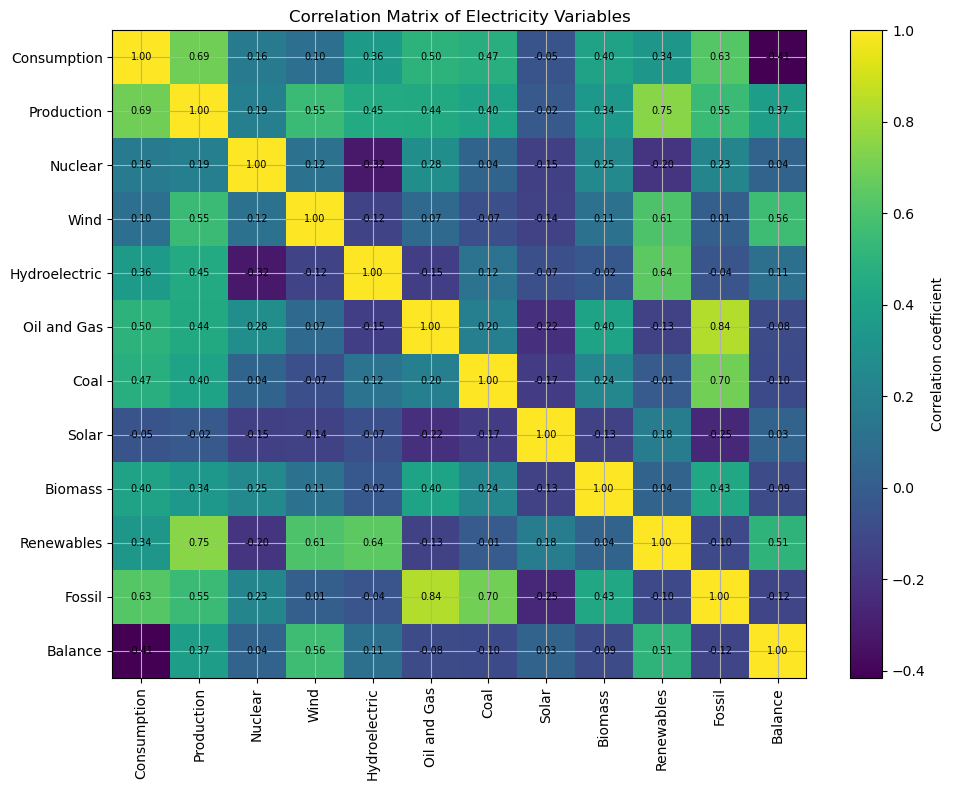

In [23]:
corr_cols = [
    "Consumption", "Production", "Nuclear", "Wind", "Hydroelectric",
    "Oil and Gas", "Coal", "Solar", "Biomass", "Renewables", "Fossil", "Balance"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation coefficient")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

plt.title("Correlation Matrix of Electricity Variables")
plt.tight_layout()
plt.savefig("../figures/figure5_correlation_heatmap.png", dpi=300)
plt.show()

In [ ]:
# Figure 6 compares the monthly share of renewable and fossil sources in electricity production.
# This plot highlights how the energy mix changes over time and whether fossil sources compensate for renewable fluctuations.

In [ ]:
# Figure 6 compares the monthly average share of renewable and fossil sources in total electricity production. 
# Renewable sources generally account for a larger share of production than fossil sources, although both components vary substantially over time. 
# The figure also suggests a complementary relationship between the two categories: when the renewable share increases, the fossil share often decreases, and vice versa. 
# This indicates that fossil sources may compensate for periods of lower renewable output, while renewable sources can reduce the relative dependence on fossil generation during favorable periods.

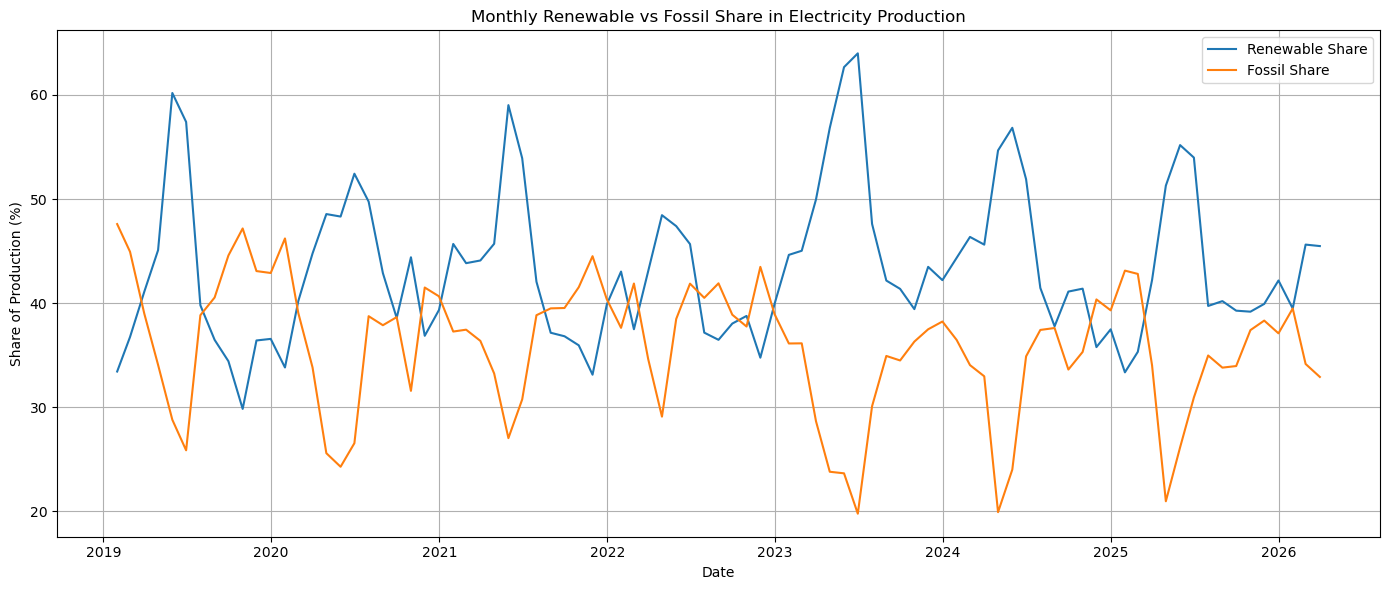

In [25]:
monthly_share = df.groupby(pd.Grouper(key="DateTime", freq="ME"))[
    ["RenewableShare", "FossilShare"]
].mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_share.index, monthly_share["RenewableShare"], label="Renewable Share")
plt.plot(monthly_share.index, monthly_share["FossilShare"], label="Fossil Share")

plt.title("Monthly Renewable vs Fossil Share in Electricity Production")
plt.xlabel("Date")
plt.ylabel("Share of Production (%)")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/figure6_renewable_vs_fossil_share.png", dpi=300)
plt.show()